In [1]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import duckdb
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

import os
os.chdir("C:/Users/kweec/python files/risk-project")

In [3]:
# подключаемся к базе
con = duckdb.connect('C:/Users/kweec/python files/risk-project/notebooks/credit_risk.db')

# читаем фичи из mart
df = con.execute("SELECT * FROM mart.features").df()
print(df.shape)
print(df['is_default'].value_counts())

(1341110, 21)
is_default
0    1073336
1     267774
Name: count, dtype: int64


In [4]:
FEATURES = [
    'dti', 'fico_avg', 'annual_inc', 'loan_amnt',
    'installment', 'open_acc', 'revol_util', 'total_acc',
    'loan_to_income', 'payment_to_income',
    'term_months', 'home_ownership', 'purpose'
]

df_model = df[FEATURES + ['is_default']].dropna()
df_model = pd.get_dummies(df_model,
                            columns=['home_ownership', 'purpose'],
                            drop_first=True)

FEATURES_ENC = [c for c in df_model.columns if c != 'is_default']

X = df_model[FEATURES_ENC]
y = df_model['is_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Фич после encoding: {len(FEATURES_ENC)}")
print(f"Строк: {X_train.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Фич после encoding: 29
Строк: 1072209


In [5]:
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': 4,
        'random_state': 42,
        'verbosity': 0,
        'eval_metric': 'auc'
    }
    
    model = xgb.XGBClassifier(**params)
    
    # Используем кросс-валидацию на 3 фолда только на тренировочной выборке
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc')
    
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) 

print(f"Лучший AUC на кросс-валидации: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

Лучший AUC на кросс-валидации: 0.7101
Лучшие параметры: {'n_estimators': 514, 'max_depth': 4, 'learning_rate': 0.13630443926042313, 'subsample': 0.9513495786950605, 'colsample_bytree': 0.7218305891045468, 'min_child_weight': 8}


In [7]:
def compute_metrics(y_true, y_pred_proba):
    auc  = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    
    # KS статистика
    defaults     = y_pred_proba[y_true == 1]
    non_defaults = y_pred_proba[y_true == 0]
    ks = stats.ks_2samp(defaults, non_defaults).statistic
    
    return {"AUC": round(auc, 4), "Gini": round(gini, 4), "KS": round(ks, 4)}

In [8]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("credit_risk_pd")

with mlflow.start_run(run_name="logistic_baseline"):
    
    model_lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    model_lr.fit(X_train_scaled, y_train)
    
    y_pred = model_lr.predict_proba(X_test_scaled)[:, 1]
    metrics = compute_metrics(y_test.values, y_pred)
    
    # логируем в MLflow
    mlflow.log_params({"C": 0.1, "max_iter": 1000, "model": "LogisticRegression"})
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(model_lr, "model")
    
    print("Логистическая регрессия:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")

2026/04/06 01:31:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 01:31:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Логистическая регрессия:
  AUC: 0.6961
  Gini: 0.3921
  KS: 0.2818


In [9]:
with mlflow.start_run(run_name="xgboost_optim"):
    
    model_xgb = xgb.XGBClassifier(
        n_estimators=514,
        max_depth=4,
        learning_rate=0.1363,
        subsample=0.9514,
        colsample_bytree=0.72,
        scale_pos_weight=4,  # компенсация дисбаланса классов 80/20
        random_state=42,
        min_child_weight = 8,
        eval_metric='auc',
        verbosity=0
    )
    
    model_xgb.fit(X_train, y_train)  # XGBoost не требует нормализации
    
    y_pred_xgb = model_xgb.predict_proba(X_test)[:, 1]
    metrics_xgb = compute_metrics(y_test.values, y_pred_xgb)
    
    mlflow.log_params({
        "n_estimators": 413,
        "max_depth": 4,
        "learning_rate": 0.12,
        "model": "XGBoost"
    })
    mlflow.log_metrics(metrics_xgb)
    mlflow.xgboost.log_model(model_xgb, "model")
    
    print("XGBoost:")
    for k, v in metrics_xgb.items():
        print(f"  {k}: {v}")

2026/04/06 01:31:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost:
  AUC: 0.7109
  Gini: 0.4219
  KS: 0.3064


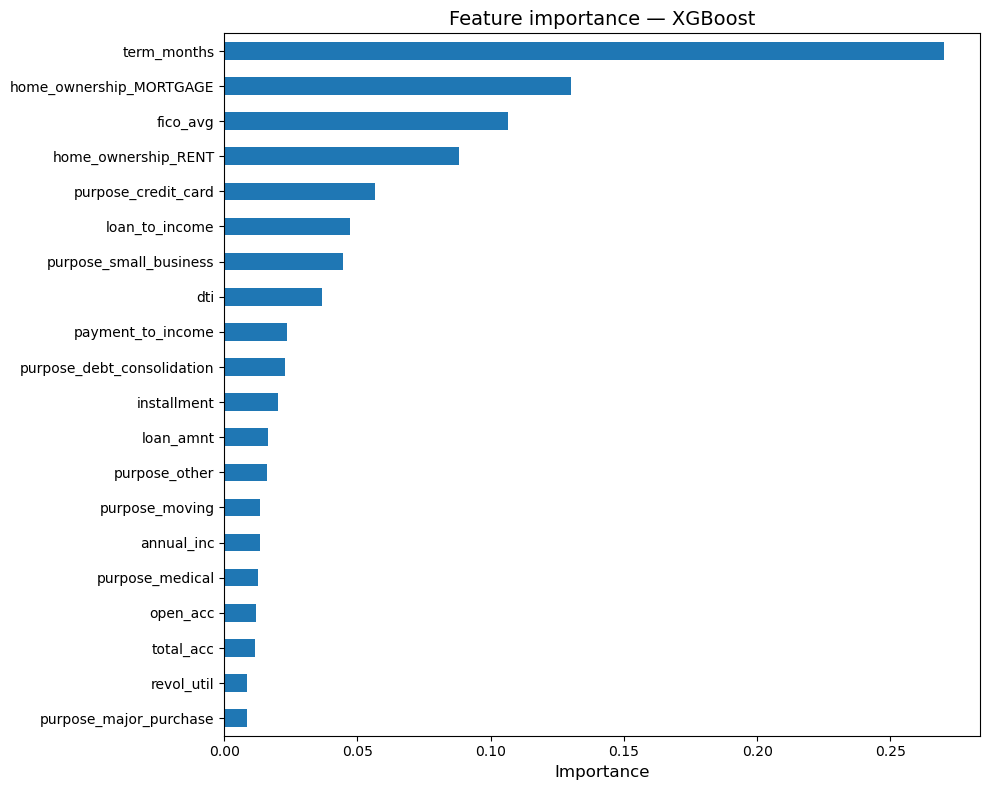

In [10]:
feat_imp = pd.Series(
    model_xgb.feature_importances_,
    index=FEATURES_ENC  # используем FEATURES_ENC, а не FEATURES
).sort_values(ascending=True)

# Для лучшей читаемости покажем топ-20 признаков
plt.figure(figsize=(10, 8))
feat_imp.tail(20).plot(kind='barh')  # tail() показывает самые важные сверху
plt.title('Feature importance — XGBoost', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
con.close()

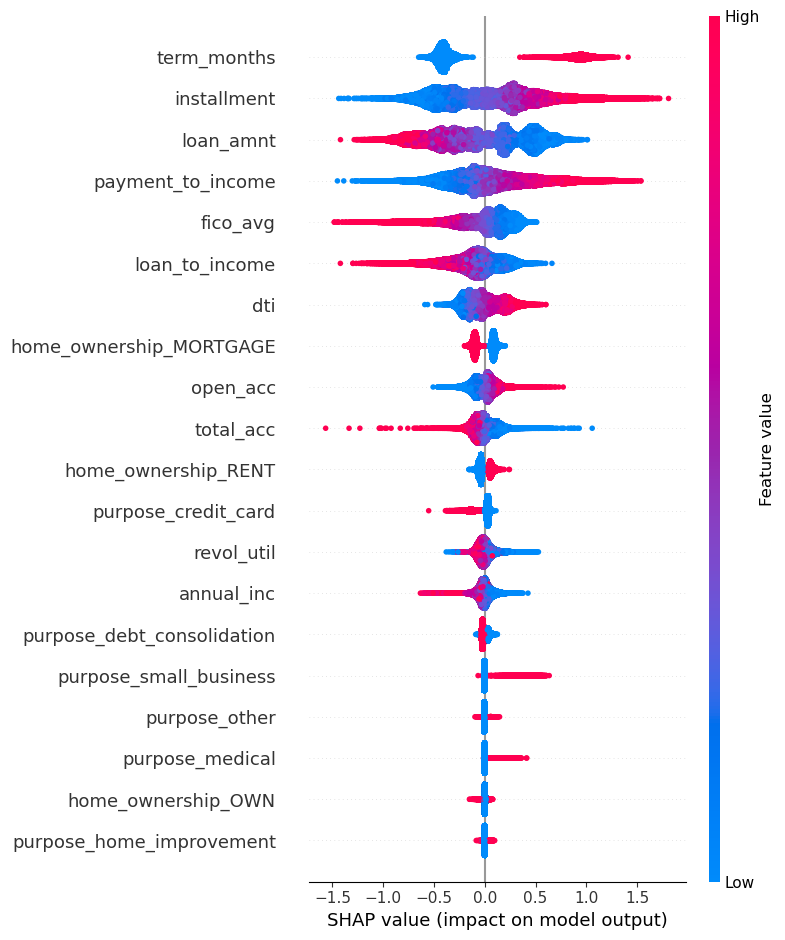

In [13]:
import shap

# Расчет SHAP значений
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# Визуализация влияния признаков на всю выборку
shap.summary_plot(shap_values, X_test)
